# SETUP - BOLLORE GALAXY SUMMARY

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import requests
import json

# For data vasualisation, source: https://www.kaggle.com/code/alexisbcook/hello-seaborn
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from pymongo import MongoClient
# change this setting to use backup data-files in data folder
use_mongodb=True

if use_mongodb:
    client = MongoClient('mongodb://localhost:27017')
    db = client["bollore_analysis_db"]
    collection = db["timeseries_data_files"]
else:
    import os
    for dirname, _, filenames in os.walk('data'):
        for filename in filenames:
            print(os.path.join(dirname, filename))

In [2]:
import request_data_av_with_mongodb

# Function to load data and reformat it as a pandas df
def load_timeseries_as_df(ticker="BOL_PA", start_date='2021-09-21', use_mongodb=True):
    if use_mongodb:
        # Check data & update if necessary
        request_data_av_with_mongodb.main(maximum_stock_quote_age=43200)
        # Read data from database
        data = collection.find_one({'_id': f'{ticker}.json'})["data"]
    else:
        with open(f'data/{ticker}.json') as json_file:
            data = json.load(json_file)
    
    timeseries_data = data["Time Series (Daily)"]

    df = pd.DataFrame(timeseries_data)
    df = df.transpose()
    
    # Backfill to start date with zeros
    date_range = pd.date_range(start=start_date, end=df.index.min(), freq='D')
    zero_df = pd.DataFrame(index=date_range, columns=df.columns).fillna(0).infer_objects()[::-1]
    df = pd.concat([df, zero_df])  
    
    # filter dates to relevant timeperiod
    df.index = pd.to_datetime(df.index)
    start_date = pd.to_datetime(start_date)
    df = df[df.index >= start_date]
            
    return df   

Connected at mongodb://localhost:27017


In [3]:
# Originally only used data from '2021-09-21' - (UMG IPO)
# Options:
default_post_umg_spin = '2021-09-21' # post UMG spin
after_havas_transferred = "2016-09-22" # after Havas transferred to vivendi

start_date= after_havas_transferred

bol_df = load_timeseries_as_df(ticker="BOL_PA", start_date=start_date, use_mongodb=use_mongodb)
odet_df = load_timeseries_as_df(ticker="ODET_PA", start_date=start_date, use_mongodb=use_mongodb)
umg_df = load_timeseries_as_df(ticker="UMG_AMS", start_date=start_date, use_mongodb=use_mongodb)
viv_df = load_timeseries_as_df(ticker="VIV_PA", start_date=start_date, use_mongodb=use_mongodb)

#ALSO:
#CAN.LON
#ALHG.PAR
#HAVAS.AMS


last data request: 430546.173029s
A new request is being made.
updated data for BOL.PA
updated data for ODET.PA
updated data for UMG.AMS
updated data for VIV.PA
updated data for CAN.LON
updated data for ALHG.PAR
updated data for HAVAS.AMS
last data request: 10.668562s
Data up to date
Next request in  43189.331438 s
last data request: 10.855465s
Data up to date
Next request in  43189.144535 s
last data request: 10.885063s
Data up to date
Next request in  43189.114937 s


C:\Users\perso\AppData\Local\Temp\ipykernel_38016\2713359599.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  zero_df = pd.DataFrame(index=date_range, columns=df.columns).fillna(0).infer_objects()[::-1]


In [ ]:
#Valuation logic (classes)
class Company:   
    def __init__(self, name, shares_outstanding, shareprice, currency='€'):
        self.name = name
        self.shares_outstanding = shares_outstanding
        self.shareprice = shareprice
        self.currency = currency

        #initialising values
        self.assets = []
        self.value = 0  
        self.discount_to_value_percent = 0
        self.outputs = {'assets': []}

        #updates .outputs with formatted values
        self.update_outputs()
     
    def market_cap(self, to_string=False):
        mkt_cap = self.shares_outstanding * self.shareprice
        if to_string:
            mkt_cap = Company.large_number_to_string(mkt_cap)
        return mkt_cap
    
    def asign_asset(self, asset, value='optional', is_company_object=False, ownership_fraction=1):
        if is_company_object:
            value_of_asset = asset.market_cap() * ownership_fraction
            name_of_asset = asset.name
        else:
            value_of_asset = value
            name_of_asset = asset
        
        self.assets += [{
            'name': name_of_asset,
            'ownership_percentage': ownership_fraction,
            'value': value_of_asset
            }]
        self.outputs['assets'] += [{
            'name': name_of_asset,
            'ownership_percentage': Company.fraction_to_percentage_string(ownership_fraction),
            'value': Company.large_number_to_string(value_of_asset)
            }]    
        self.value += value_of_asset
        self.discount_to_value_percent = Company.fraction_to_percentage_string(1 - (self.market_cap() / self.value))        
        self.update_outputs()

    def update_outputs(self):
        new_outputs = {
            'name': self.name,
            'title': str(self),
            'market_cap': self.market_cap(to_string=True),
            'shares_outstanding': Company.large_number_to_string(self.shares_outstanding),
            'value': Company.large_number_to_string(self.value),
            'currency': self.currency,
            'share_price': self.shareprice
        }
        self.add_output(new_outputs)

    def add_output(self, new_outputs):
        self.outputs.update(new_outputs)

    def __str__(self):
        return f'{self.name} (mkt cap {self.market_cap(to_string=True)} @ {self.shareprice} per share)'
    
    @staticmethod
    def large_number_to_string(value):
        if value > 1000000000:
            value = f"{str(round(value/1000000000,1))}B"
        else:
            value = f"{str(int(round(value/1000000,0)))}M"
        return value
    
    @staticmethod
    def fraction_to_percentage_string(value):
        percentage_string = ''
        if value > 0.10:
            percentage_string = f'{int(round(value * 100, 0))}%'
        else:
            percentage_string = f'{round(value * 100, 1)}%'
        return percentage_string

class CircularOwnership:

    def __init__(self, company_1, company_1_outside_ownership, company_2, company_2_outside_ownership):
        # assumes all shares not held by outside owners are cross-held
        self.company_1 = company_1
        self.company_2 = company_2
        self.companies = [company_1, company_2]
        self.company_1_outside_ownership = company_1_outside_ownership
        self.company_2_outside_ownership = company_2_outside_ownership
        self.company_1_owned_by_company_2 = 1 - company_1_outside_ownership
        self.company_2_owned_by_company_1 = 1 - company_2_outside_ownership
        self.unassigned_assets_from_company_1 = company_1.value
        self.unassigned_assets_from_company_2 = company_2.value

        #initialising values
        self.assets_owned_by_company_1_outside_shareholders = 0
        self.assets_owned_by_company_2_outside_shareholders = 0
        self.proportion_of_assets_owned_by_company_1_outside_shareholders = 0
        self.proportion_of_assets_owned_by_company_2_outside_shareholders = 0

        self.distribution_of_assets_iterative()
        self.update_outputs_of_subsidiaries()

    # def distribution_of_assets_analytical(self):
    #     """
    #     - analytical solution - only for a simplified case where company_1 owns all assets
    #     """
    #     self.proportion_of_assets_owned_by_company_1_outside_shareholders = self.company_1_outside_ownership / (1 - (self.company_1_owned_by_company_2 * self.company_2_owned_by_company_1))

    #     self.proportion_of_assets_owned_by_company_2_outside_shareholders = (
    #         self.company_2_outside_ownership * self.company_1_owned_by_company_2
    #         / (1 - (self.company_2_owned_by_company_1 * self.company_1_owned_by_company_2))
    #     )

    #     print(f'Proportion Of Assets Owned By {self.company_1.name} Outside Shareholders', self.proportion_of_assets_owned_by_company_1_outside_shareholders, f'Proportion Of Assets Owned By {self.company_2.name} Outside Shareholders', self.proportion_of_assets_owned_by_company_2_outside_shareholders)

    def distribution_of_assets_iterative(self):
        total_assets = self.unassigned_assets_from_company_1 + self.unassigned_assets_from_company_2 + self.assets_owned_by_company_1_outside_shareholders + self.assets_owned_by_company_2_outside_shareholders

        while (self.unassigned_assets_from_company_1 + self.unassigned_assets_from_company_2) > 0.1:
            #section 1 of cycle
            self.assets_owned_by_company_1_outside_shareholders += self.unassigned_assets_from_company_1 * self.company_1_outside_ownership
            self.unassigned_assets_from_company_1 -= self.unassigned_assets_from_company_1 * self.company_1_outside_ownership
            self.assets_owned_by_company_2_outside_shareholders += self.unassigned_assets_from_company_2 * self.company_2_outside_ownership
            self.unassigned_assets_from_company_2 -= self.unassigned_assets_from_company_2 * self.company_2_outside_ownership
            # print(f'{self.assets_owned_by_company_1_outside_shareholders}, {self.unassigned_assets_from_company_1}, {self.assets_owned_by_company_2_outside_shareholders}, {self.unassigned_assets_from_company_2}')

            #section 2 of cycle
            self.assets_owned_by_company_1_outside_shareholders += self.unassigned_assets_from_company_2 * self.company_1_outside_ownership
            self.unassigned_assets_from_company_2 -= self.unassigned_assets_from_company_2 * self.company_1_outside_ownership
            self.assets_owned_by_company_2_outside_shareholders += self.unassigned_assets_from_company_1 * self.company_2_outside_ownership
            self.unassigned_assets_from_company_1 -= self.unassigned_assets_from_company_1 * self.company_2_outside_ownership
            # print(f'{self.assets_owned_by_company_1_outside_shareholders}, {self.unassigned_assets_from_company_1}, {self.assets_owned_by_company_2_outside_shareholders}, {self.unassigned_assets_from_company_2}')

        self.proportion_of_assets_owned_by_company_1_outside_shareholders = self.assets_owned_by_company_1_outside_shareholders / total_assets
        self.proportion_of_assets_owned_by_company_2_outside_shareholders = self.assets_owned_by_company_2_outside_shareholders / total_assets

        # print(f'{self.assets_owned_by_company_1_outside_shareholders}, {self.assets_owned_by_company_2_outside_shareholders}')

    def update_outputs_of_subsidiaries(self):
        add_to_company_1_ouputs = {
            'outside_shares': f'{Company.fraction_to_percentage_string(self.company_1_outside_ownership)}',
            'cross_holding_description': f'Owns {Company.fraction_to_percentage_string(self.company_2_owned_by_company_1)} of {self.company_2.name} →',
            'economic_ownership_percentage': f'{Company.fraction_to_percentage_string(self.proportion_of_assets_owned_by_company_1_outside_shareholders)}',
            'value_of_economic_ownership': f'{Company.large_number_to_string(self.assets_owned_by_company_1_outside_shareholders)}',
            'market_cap_of_outside_shares': f'{Company.large_number_to_string(self.company_1.market_cap() * self.company_1_outside_ownership)}',
            'discount': f'-{Company.fraction_to_percentage_string(1 - (self.company_1.market_cap() * self.company_1_outside_ownership) /self.assets_owned_by_company_1_outside_shareholders)}',
            'discount_num': -(1 - (self.company_1.market_cap() * self.company_1_outside_ownership) /self.assets_owned_by_company_1_outside_shareholders)
        }
        add_to_company_2_ouputs = {
            'outside_shares': f'{Company.fraction_to_percentage_string(self.company_2_outside_ownership)}',
            'cross_holding_description': f'← Owns {Company.fraction_to_percentage_string(self.company_1_owned_by_company_2)} of {self.company_1.name}',
            'economic_ownership_percentage': f'{Company.fraction_to_percentage_string(self.proportion_of_assets_owned_by_company_2_outside_shareholders)}',
            'value_of_economic_ownership': f'{Company.large_number_to_string(self.assets_owned_by_company_2_outside_shareholders)}',
            'market_cap_of_outside_shares': f'{Company.large_number_to_string(self.company_2.market_cap() * self.company_2_outside_ownership)}',
            'discount': f'-{Company.fraction_to_percentage_string(1 - (self.company_2.market_cap() * self.company_2_outside_ownership) /self.assets_owned_by_company_2_outside_shareholders)}',
            'discount_num': -(1 - (self.company_2.market_cap() * self.company_2_outside_ownership) /self.assets_owned_by_company_2_outside_shareholders)

        }
        
        self.company_1.add_output(add_to_company_1_ouputs)
        self.company_2.add_output(add_to_company_2_ouputs)
        

    def __str__(self):
        return f'{self.company_1} owns {round(self.company_2_owned_by_company_1 * 100,3)}% of {self.company_2} and {self.company_2} owns {round(self.company_1_owned_by_company_2 * 100,3)}% of {self.company_1}'


In [5]:
# assigns assets, 
def main_function(bollore_shareprice, umg_shareprice, odet_shareprice, vivindi_shareprice):
    # Bollore 'galaxy'
    bollore = Company('Bolloré SE', shares_outstanding=(2902650243 - 99.1 * 10 ** 6) , shareprice=bollore_shareprice)
    umg = Company('Universal Music Group', shares_outstanding=1.81 * 10 ** 9, shareprice=umg_shareprice)
    odet = Company("Compagnie de l'Odet", shares_outstanding=6590000, shareprice=odet_shareprice)
    vivendi = Company("Vivendi", shares_outstanding=1139051437, shareprice=vivindi_shareprice)

    # Asign Assets
    bollore.asign_asset(asset=umg, is_company_object=True, ownership_fraction=0.1810) # was 17.7%, cash flow statement implies they've been buying
    odet.asign_asset(asset=umg, is_company_object=True, ownership_fraction=0.0033)
    bollore.asign_asset(asset=vivendi, is_company_object=True, ownership_fraction=0.29)
    odet.asign_asset(asset=vivendi, is_company_object=True, ownership_fraction=0.005)
    bollore.asign_asset('Cash', (6.035*10**9)) #as of june 30th. Source: First half 2024 results (presentation of account)

    bollore_odet_group = CircularOwnership(company_1=bollore, company_1_outside_ownership=0.292, company_2=odet, company_2_outside_ownership=0.16)
    
    return bollore, umg, odet, vivendi, bollore_odet_group

def odet_discount(bollore_shareprice, umg_shareprice, odet_shareprice, vivindi_shareprice):
    bollore, umg, odet, vivendi, bollore_odet_group = main_function(bollore_shareprice, umg_shareprice, odet_shareprice, vivindi_shareprice)
    return odet.outputs["discount_num"]

def bollore_discount(bollore_shareprice, umg_shareprice, odet_shareprice, vivindi_shareprice):
    bollore, umg, odet, vivendi, bollore_odet_group = main_function(bollore_shareprice, umg_shareprice, odet_shareprice, vivindi_shareprice)
    return bollore.outputs["discount_num"]

In [6]:
half1_df = pd.merge(bol_df, odet_df, left_index=True, right_index=True, suffixes=('_bol', '_odet'))
half2_df = pd.merge(umg_df, viv_df, left_index=True, right_index=True, suffixes=('_umg', '_viv'))
main_df = pd.merge(half1_df, half2_df, left_index=True, right_index=True)

main_df = main_df.apply(pd.to_numeric, errors='coerce')

#switching from kaggle to VSCode, needed to reverse dataframe vertically here
main_df= main_df.iloc[::-1]

print("---data merged---")

---data merged---


In [7]:
# Calculate the valuation discount for each of Odet & Bollore

# choose what time of day to pick data from
time_price = "4. close"

# Can use apply method to apply the function to each row:
main_df["discount_odet"] = main_df.apply(lambda row: odet_discount(row[time_price+"_bol"], row[time_price+"_umg"], row[time_price+"_odet"], row[time_price+"_viv"]), axis=1)
main_df["discount_bol"] = main_df.apply(lambda row: bollore_discount(row[time_price+"_bol"], row[time_price+"_umg"], row[time_price+"_odet"], row[time_price+"_viv"]), axis=1)

# OLD DISCOUNT RATIO - 
# main_df["discount_ratio"] = 1 - main_df["discount_odet"] / main_df["discount_bol"]

# Correct measure: additional discount of Odet relative to Bollore valuation
main_df["discount_ratio"] = -(1 - (1 + main_df["discount_odet"]) / (1 + main_df["discount_bol"]))

# although mainly focussed on discount, Odet/Bollore price ratio is probably a useful feature too?
# REMOVED: after correcting discount calculation price ratio was co-linear with discount ratio over, so removed as a redundant feature
"""
normalisation_factor = main_df[time_price + "_odet"].mean() / main_df[time_price + "_bol"].mean()
main_df["price_ratio"] = (main_df[time_price + "_odet"] / main_df[time_price + "_bol"]) / normalisation_factor
"""

# print(main_df.head())

C:\Users\perso\AppData\Local\Temp\ipykernel_38016\740615673.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  self.discount_to_value_percent = Company.fraction_to_percentage_string(1 - (self.market_cap() / self.value))
C:\Users\perso\AppData\Local\Temp\ipykernel_38016\740615673.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  self.discount_to_value_percent = Company.fraction_to_percentage_string(1 - (self.market_cap() / self.value))


'\nnormalisation_factor = main_df[time_price + "_odet"].mean() / main_df[time_price + "_bol"].mean()\nmain_df["price_ratio"] = (main_df[time_price + "_odet"] / main_df[time_price + "_bol"]) / normalisation_factor\n'

# INTRO

as of: 08/08/2025
discount_bol: -0.6251208248123925
discount_odet: -0.6409135636384675


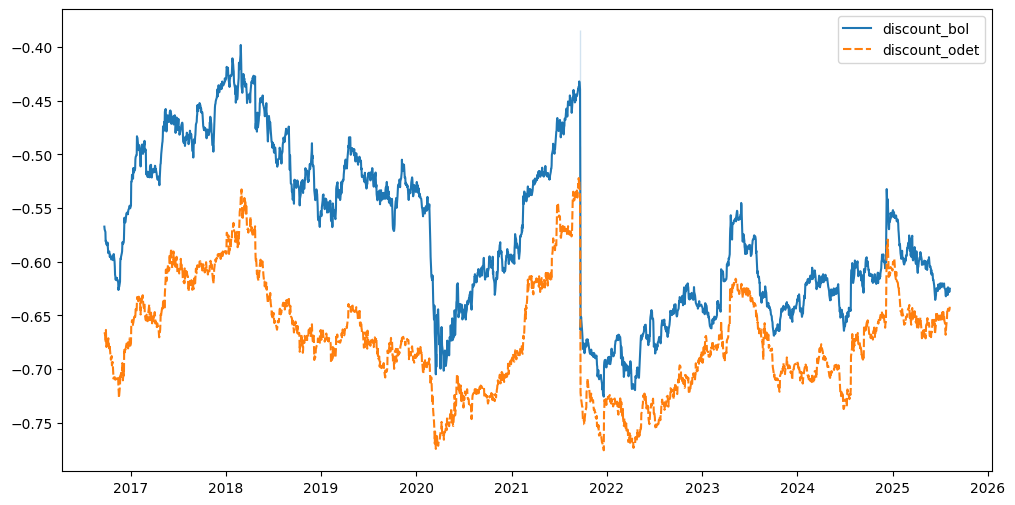

In [8]:
# Data visualisation, starting code - https://www.kaggle.com/code/alexisbcook/hello-seaborn
# Set the width and height of the figure
plt.figure(figsize=(12,6))

sns.lineplot(data=main_df[["discount_bol", "discount_odet"]])

print(f'as of: {main_df.index[-1].strftime('%d/%m/%Y')}') # Format the date as DD/MM/YYYY
print("discount_bol:", main_df["discount_bol"].iloc[-1])
print("discount_odet:", main_df["discount_odet"].iloc[-1])

# FUNCTIONS + PCA + Random Forest

In [9]:
# generalised function for approach used below
def remove_columns_starting_with(start_df, prefixes_to_remove):
    columns_to_remove = [col for col in start_df.columns if any(col.startswith(prefix) for prefix in prefixes_to_remove)]
    return_df = start_df.drop(columns=columns_to_remove)
    return return_df

In [10]:
# Feature engineering (feature selection)
# Removing all columns for open/high/low price for now (so we can focus on closing price)
columns_to_remove = [col for col in main_df.columns if any(col.startswith(prefix) for prefix in ('1. open', '2. high', '3. low', '5. volume'))]
# if col.startswith('1. open') or col.startswith('2. high') ... would have been alternate approach

end_day_df = main_df.drop(columns=columns_to_remove)
#NOTE - open/close/high/low shareprices had extremely close correlation to one another (>=0.99) & highly associated in PCA, so removed to simplify the analysis

In [11]:
# profit from buying Odet and Selling Bollore
def trading_profit(odet_new, odet_old, bol_new, bol_old, method=1):
    # Method 1: profit multiplier, buying 50% odet and shorting 50% bollore over the timeperiod
    """ 
    This strategy combines with the 'null-strategy' of owning 50/50 odet/bollore, to show the pair-dependent
    'market neutral' component of swapping between owning odet & bollore (long only)
    
    Odet( 0.5) +  Bollore( 0.5)    {null strategy}
    Odet(+0.5) +  Bollore(-0.5)    {pair-choice dependent component - mkt neutral} {or visa versa}
    -----------------------
    Odet( 1.0) +  Bollore( 0.0)    {practical strategy, choosing which of pair to own}
    """
    if (method == 1):
        return (
        1 + 0.5 * (( odet_new / odet_old)
        -
        ( bol_new / bol_old)
        ))
    
    # Method 2: profit multiplier, buying odet and shorting bollore over the timeperiod
    # Added onto null hypothesis this would give Odet (+1.5), Bollore (-0.5), but usefull for LONG/SHORT only
    elif (method == 2):
        return (
        1 + (( odet_new / odet_old)
        -
        ( bol_new / bol_old)
        ))
    
    # Method 3: profit ratio, buying odet compared to buying bollore
    # Use with caution
    elif (method == 3):
        return (
        (odet_new / odet_old) / (bol_new / bol_old)
        )
        
    
    

In [12]:
# Target variable - goal is to figure out whether available information can provide good signals for trading the ODET / BOL pair.
# As a first attempt at a target variable I'm going to propose relative profit/loss from buying ODET & selling BOL & holding for set number of days

# Shift the values of the desired column 60 days ahead
days_ahead = 120

dummy_df = pd.DataFrame()
dummy_df[f'price_{days_ahead}_days_ahead' + '_odet'] = main_df[time_price + "_odet"].shift(+ days_ahead)
dummy_df[f'price_{days_ahead}_days_ahead' + '_bol'] = main_df[time_price + "_bol"].shift(+ days_ahead)

# NEW: - attempts to use generalised function appeared to work, but caused some errors
"""
main_df[f'trading_profit_{days_ahead}_days_frctn'] = main_df.apply(
    lambda row: -1 + trading_profit(
        odet_new= dummy_df.loc[row.name, f'price_{days_ahead}_days_ahead' + '_odet'],
        odet_old= row[time_price + "_odet"],
        bol_new= dummy_df.loc[row.name, f'price_{days_ahead}_days_ahead' + '_bol'],
        bol_old= row[time_price + "_bol"],
        method=1
    ),
    axis=1
)
"""

# OLD: - functions reliably
main_df[f'trading_profit_{days_ahead}_days_frctn'] = (
    ( dummy_df[f'price_{days_ahead}_days_ahead' + '_odet'] / main_df[time_price + "_odet"]) -
    ( dummy_df[f'price_{days_ahead}_days_ahead' + '_bol'] / main_df[time_price + "_bol"])
    )

# number of rows=days_ahead of NaN need to be dropped for data to be useful for machine learning later (data wrangling)
main_df = main_df.dropna()

print("---")

---


In [13]:
# PCA:
# Reference: https://www.kaggle.com/code/ryanholbrook/principal-component-analysis

# 1st select and standardise data:

X = main_df.copy().drop(columns=columns_to_remove) #removes 'wrong' time of day
# X = remove_columns_starting_with(start_df=X, prefixes_to_remove=("5. volume"))

y = X.pop(f'trading_profit_{days_ahead}_days_frctn')

# Standardize
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

In [14]:
# Reference: https://www.kaggle.com/code/ryanholbrook/principal-component-analysis
from sklearn.decomposition import PCA

# Create principal components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Convert to dataframe
component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=component_names)


In [15]:
# Reference: https://www.kaggle.com/code/ryanholbrook/principal-component-analysis
loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns=component_names,  # so the columns are the principal components
    index=X.columns,  # and the rows are the original features
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
4. close_bol,0.442395,0.241156,-0.254753,0.460590,-0.255271,-0.208380,-0.600419
4. close_odet,0.476720,0.218785,-0.168401,0.087954,-0.405221,0.372856,0.620928
4. close_umg,0.497138,-0.093649,0.018519,0.241407,0.795039,-0.106572,0.204985
4. close_viv,-0.134322,-0.275120,-0.935127,-0.138938,0.104957,-0.005778,0.038097
discount_odet,-0.111539,0.699678,-0.132164,-0.233261,0.081779,-0.597974,0.248740
discount_bol,-0.321308,0.552301,-0.119773,0.203594,0.334683,0.628913,-0.168476
discount_ratio,0.442895,0.122188,0.011157,-0.778896,0.093970,0.230350,-0.346727


<Axes: >

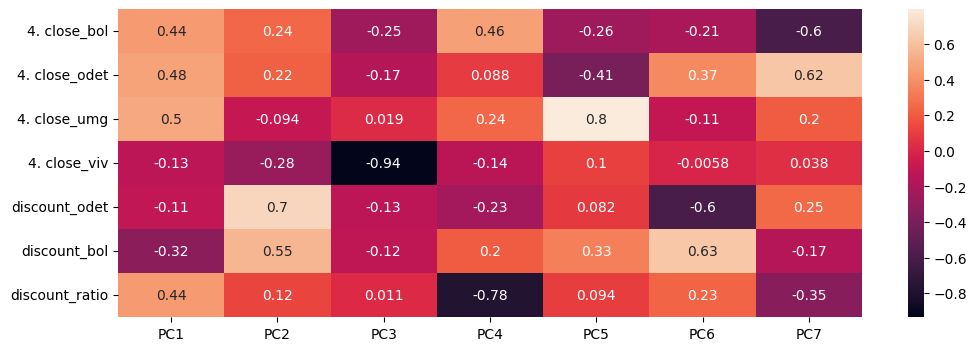

In [16]:
plt.figure(figsize=(12,4))
sns.heatmap(loadings, annot=True)

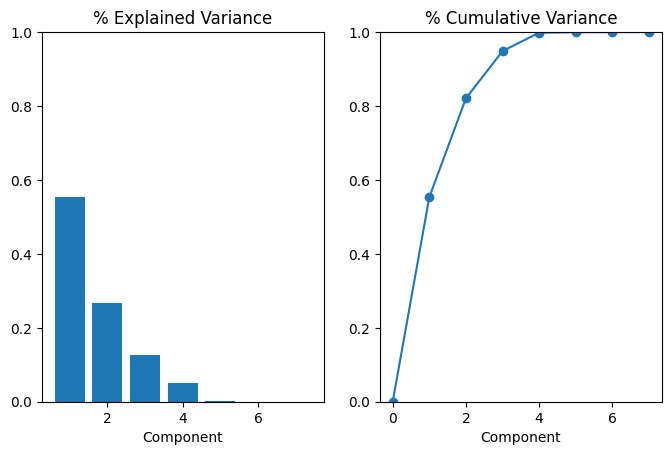

In [17]:
# Reference: https://www.kaggle.com/code/ryanholbrook/principal-component-analysis
# Look at explained variance
def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

plot_variance(pca);

# Backtesting - functions

In [18]:
#null-functions (trade every opportunity)
def strategy_buy_default(row):
    return True

def strategy_sell_default(row):
    return True

# as currently set up backtests using absolute price
# takes into account the overal trend in the Bol/Odet stockprice
# not just relative valuation as intended
def backtest(strategy_buy, strategy_sell, df, trading_costs = 0):
    #starting state
    owned = "none"
    old = "NA"
    profit_ratios = []    
    
    for index, row in df.iterrows():
        if (owned != "_bol" and strategy_sell(row)):
            if (old != "NA"):
                # calculate profit ratio
                new = row["4. close" + owned]
                profit_ratio = (new / old) - trading_costs
                
                profit_ratios.append(profit_ratio)
            
            # set new state
            owned = "_bol" #buying this
            old = row["4. close" + owned]
            
        elif (owned != "_odet" and strategy_buy(row)):
            if (old != "NA"):
                # calculate profit ratio
                new = row["4. close" + owned]
                profit_ratio = (new / old) - trading_costs
                
                profit_ratios.append(profit_ratio)
                
            # set new state
            owned = "_odet" # buying this
            old = row["4. close" + owned]
        #--------------------------------
    print("absolute profit",np.prod(profit_ratios))
    return pd.DataFrame(profit_ratios)

#------------------------------------------------------------------------

def backtest_relative(strategy_buy, strategy_sell, df, trading_costs = 0, method=1):
    # Function adjusted to give RELATIVE profit ratios and ignore long-term trend in overal price for the Bol/Odet pair!
    # Method 1: profit multiplier, buying 50% odet and shorting 50% bollore over the timeperiod
    """ 
    This strategy combines with the 'null-strategy' of owning 50/50 odet/bollore, to show the pair-dependent
    'market neutral' component of swapping between owning odet & bollore (long only)
    
    Odet( 0.5) +  Bollore( 0.5)    {null strategy}
    Odet(+0.5) +  Bollore(-0.5)    {pair-choice dependent component - mkt neutral} {or visa versa}
    -----------------------
    Odet( 1.0) +  Bollore( 0.0)    {practical strategy, choosing which of pair to own}
    """
    
    #starting state
    owned = "none"
    old = "NA"
    profit_ratios = []    
    
    for index, row in df.iterrows():
        # buying bol
        if (owned != "_bol" and strategy_sell(row)):
            if (owned != "none"):
                # calculate profit ratio
                odet_new = row["4. close" + "_odet"]
                bol_new = row["4. close" + "_bol"]
                profit_ratio = trading_profit(odet_new, odet_old, bol_new, bol_old, method) - trading_costs
                
                profit_ratios.append(profit_ratio)
            
            # set new state
            owned = "_bol" #buying this
            odet_old = row["4. close" + "_odet"]
            bol_old = row["4. close" + "_bol"]
        
        # buying odet
        elif (owned != "_odet" and strategy_buy(row)):
            if (owned != "none"):
                # calculate profit ratio
                odet_new = row["4. close" + "_odet"]
                bol_new = row["4. close" + "_bol"]
                profit_ratio = 1/trading_profit(odet_new, odet_old, bol_new, bol_old, method) - trading_costs
                
                profit_ratios.append(profit_ratio)
                
            # set new state
            owned = "_odet" # buying this
            odet_old = row["4. close" + "_odet"]
            bol_old = row["4. close" + "_bol"]
        #--------------------------------
    print("relative profit multiplier:", np.prod(profit_ratios))
    return pd.DataFrame(profit_ratios)

In [19]:
def number_of_years (backtest_df):
    start_date = backtest_df.index[0]
    end_date = backtest_df.index[-1]
    
    num_years = (end_date - start_date).days / 365.25
    
    return num_years

def annualised_return (profit_ratio_df, backtest_df):
    # function returns annualised returns for the dataframe output of a backtest function
    
    # start_date = backtest_df.index[0]
    # end_date = backtest_df.index[-1]
    
    total_multiplier = profit_ratio_df.prod()

    num_years= number_of_years(backtest_df)#(end_date - start_date).days / 365.25
    return total_multiplier ** (1 / num_years) - 1 

# BACKTEST GRAPHS

In [20]:
# moving averages
# consider incorporating some of these as features:
number_days_ma = 80

y_ma = main_df["discount_ratio"].rolling(number_days_ma, center=False).mean()
y_std = main_df["discount_ratio"].rolling(number_days_ma, center=False).std()

# reasonable starting point for a strategy:
weighting = 1.5 #default 1.5
y_sell = y_ma + y_std * weighting
y_buy = y_ma - y_std * weighting

main_df["mean_ma"] = y_ma
main_df[f"upper_{weighting}_std_bound_ma"] = y_sell
main_df[f"lower_{weighting}_std_bound_ma"] = y_buy


data to: 08/08/2025
bollore: -62.51208248123925% odet: -64.09135636384676%
bollore: 37.48791751876075% odet: 35.90864363615324%


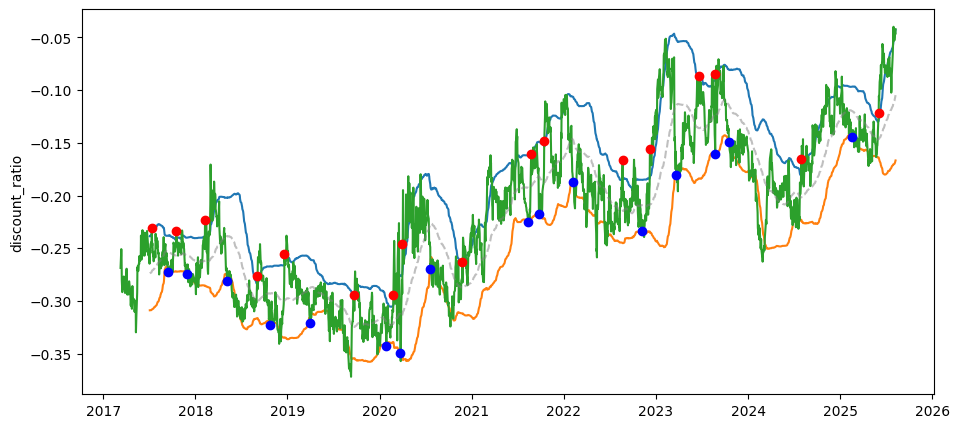

In [21]:
# check what data is being used
print(f'data to: {main_df.index[-1].strftime('%d/%m/%Y')}') # Format the date as DD/MM/YYYY

plt.figure(figsize=(11, 5))
sns.lineplot(data=y_sell)
sns.lineplot(data=y_buy)
sns.lineplot(data=main_df["discount_ratio"])
sns.lineplot(data=y_ma, linestyle='--', color='grey', alpha=0.5)
      
owned = "null"
for i in range(1, len(main_df)):
    if (main_df["discount_ratio"].iloc[i] >= main_df[f"upper_{weighting}_std_bound_ma"].iloc[i-1] and 
        main_df["discount_ratio"].iloc[i-1] < main_df[f"upper_{weighting}_std_bound_ma"].iloc[i] and 
        owned != "bol"):
        plt.scatter(main_df.index[i], main_df["discount_ratio"].iloc[i], color='red', zorder=5)
        owned = "bol"
    elif (main_df["discount_ratio"].iloc[i] <= main_df[f"lower_{weighting}_std_bound_ma"].iloc[i-1] and 
          main_df["discount_ratio"].iloc[i-1] > main_df[f"lower_{weighting}_std_bound_ma"].iloc[i] and 
          owned != "odet"):
        plt.scatter(main_df.index[i], main_df["discount_ratio"].iloc[i], color='blue', zorder=5)
        owned = "odet"
        
backtest_df = main_df.dropna()

print(f'bollore: {100*main_df["discount_bol"].iloc[-1]}% odet: {100*main_df["discount_odet"].iloc[-1]}%')
print(f'bollore: {100 + 100*main_df["discount_bol"].iloc[-1]}% odet: {100 + 100*main_df["discount_odet"].iloc[-1]}%')


data to: 08/08/2025


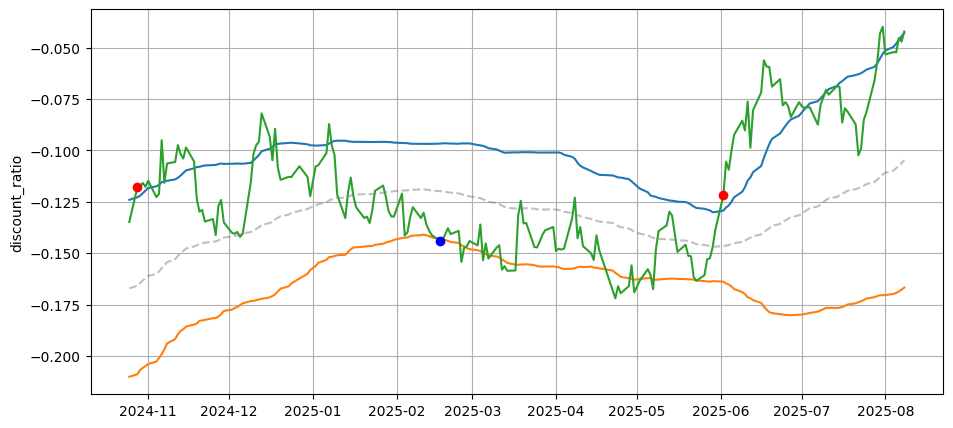

In [22]:
# check what data is being used
print(f'data to: {main_df.index[-1].strftime('%d/%m/%Y')}') # Format the date as DD/MM/YYYY

days_zoom_into = 200

# Select the last 30 entries
last_entries_df = main_df.iloc[-days_zoom_into:]

# Plotting
plt.figure(figsize=(11, 5))
sns.lineplot(data=y_sell.iloc[-days_zoom_into:])
sns.lineplot(data=y_buy.iloc[-days_zoom_into:])
sns.lineplot(data=last_entries_df["discount_ratio"])
sns.lineplot(data=y_ma.iloc[-days_zoom_into:], linestyle='--', color='grey', alpha=0.5)

owned = "null"
for i in range(1, len(last_entries_df)):
    if (last_entries_df["discount_ratio"].iloc[i] >= last_entries_df[f"upper_{weighting}_std_bound_ma"].iloc[i-1] and 
        last_entries_df["discount_ratio"].iloc[i-1] < last_entries_df[f"upper_{weighting}_std_bound_ma"].iloc[i] and 
        owned != "bol"):
        plt.scatter(last_entries_df.index[i], last_entries_df["discount_ratio"].iloc[i], color='red', zorder=5)
        owned = "bol"
    elif (last_entries_df["discount_ratio"].iloc[i] <= last_entries_df[f"lower_{weighting}_std_bound_ma"].iloc[i-1] and 
          last_entries_df["discount_ratio"].iloc[i-1] > last_entries_df[f"lower_{weighting}_std_bound_ma"].iloc[i] and 
          owned != "odet"):
        plt.scatter(last_entries_df.index[i], last_entries_df["discount_ratio"].iloc[i], color='blue', zorder=5)
        owned = "odet"


plt.grid(True)        
plt.show()

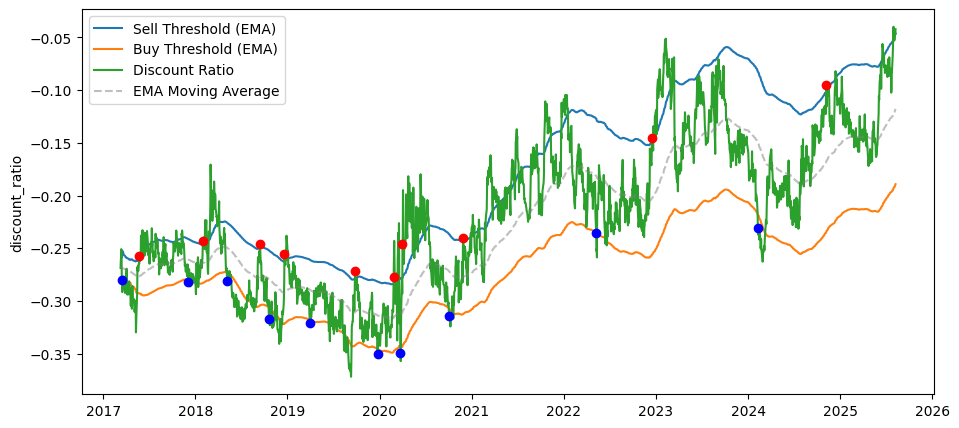

bollore: -62.51208248123925% odet: -64.09135636384676%
bollore: 37.48791751876075% odet: 35.90864363615324%


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# OPTIONS
weighting_cum = 1  # Default is 1
moving_avg_type = "EMA"  # Choose between "ARIMA" or "EMA"
alpha_value = 0.01  # Adjust this value as needed

std_type = "expanding" # Choose "expanding" or "rolling"
rolling_window_size = round(2/alpha_value - 1)  #EMA: N(effective) = 2/alpha - 1

# Compute cumulative standard deviation
if std_type == "expanding":
    y_cum_std_new = main_df["discount_ratio"].expanding().std()
elif std_type == "rolling":
    y_cum_std_new = main_df["discount_ratio"].rolling(window=rolling_window_size, min_periods=1).std()
else:
    raise ValueError("Invalid std_type. Choose either 'expanding' or 'rolling'.")

# Compute moving average based on user selection
if moving_avg_type == "EMA":
    # Use expanding Exponential Moving Average (EMA)
    main_df["cumulative_mean_new"] = main_df["discount_ratio"].expanding().apply(
        lambda x: pd.Series(x).ewm(alpha=alpha_value, adjust=False).mean().iloc[-1], raw=True
    )

# Compute buy and sell thresholds
y_sell_cum = main_df["cumulative_mean_new"] + y_cum_std_new * weighting_cum
y_buy_cum = main_df["cumulative_mean_new"] - y_cum_std_new * weighting_cum

# Store in DataFrame without overwriting existing columns
main_df[f"upper_{weighting_cum}_std_bound_cum_new"] = y_sell_cum
main_df[f"lower_{weighting_cum}_std_bound_cum_new"] = y_buy_cum

# Plot results separately
plt.figure(figsize=(11, 5))
sns.lineplot(data=y_sell_cum, label=f"Sell Threshold ({moving_avg_type})")
sns.lineplot(data=y_buy_cum, label=f"Buy Threshold ({moving_avg_type})")
sns.lineplot(data=main_df["discount_ratio"], label="Discount Ratio")
sns.lineplot(data=main_df["cumulative_mean_new"], linestyle="--", color="grey", alpha=0.5, label=f"{moving_avg_type} Moving Average")

# Mark buy/sell signals without interfering with the original
owned_cum = "null"
for i in range(1, len(main_df)):
    if (main_df["discount_ratio"].iloc[i] >= main_df[f"upper_{weighting_cum}_std_bound_cum_new"].iloc[i-1] and 
        main_df["discount_ratio"].iloc[i-1] < main_df[f"upper_{weighting_cum}_std_bound_cum_new"].iloc[i] and 
        owned_cum != "bol"):
        plt.scatter(main_df.index[i], main_df["discount_ratio"].iloc[i], color='red', zorder=5, label="Sell Signal")
        owned_cum = "bol"
    elif (main_df["discount_ratio"].iloc[i] <= main_df[f"lower_{weighting_cum}_std_bound_cum_new"].iloc[i-1] and 
          main_df["discount_ratio"].iloc[i-1] > main_df[f"lower_{weighting_cum}_std_bound_cum_new"].iloc[i] and 
          owned_cum != "odet"):
        plt.scatter(main_df.index[i], main_df["discount_ratio"].iloc[i], color='blue', zorder=5, label="Buy Signal")
        owned_cum = "odet"

# plt.legend()
plt.show()

# Print latest discount values separately
print(f'bollore: {100*main_df["discount_bol"].iloc[-1]}% odet: {100*main_df["discount_odet"].iloc[-1]}%')
print(f'bollore: {100 + 100*main_df["discount_bol"].iloc[-1]}% odet: {100 + 100*main_df["discount_odet"].iloc[-1]}%')


# BACKTEST CALCULATIONS

In [24]:
trading_costs = 0.006

print("context - trade every opportunity:")
trade_every_opportunity = backtest_relative(strategy_buy_default, strategy_sell_default, backtest_df, trading_costs)
print("number of trades", len(trade_every_opportunity))
print("average returns",trade_every_opportunity.mean())

print("-----")

print("number of years", number_of_years(backtest_df))
print("buy and hold odet:", backtest_df[time_price + "_odet"].iloc[-1]/backtest_df[time_price + "_odet"].iloc[0])
print("buy and hold bollore:", backtest_df[time_price + "_bol"].iloc[-1]/backtest_df[time_price + "_bol"].iloc[0])
print("null strategy, buy and hold Odet (0.5) & Bol (0.5):", (backtest_df[time_price + "_odet"].iloc[-1]/backtest_df[time_price + "_odet"].iloc[0] + backtest_df[time_price + "_bol"].iloc[-1]/backtest_df[time_price + "_bol"].iloc[0])/2)

def strategy_buy(row):
    return row["discount_ratio"] < row[f"lower_{weighting}_std_bound_ma"] 

def strategy_sell(row):
    return row["discount_ratio"] > row[f"upper_{weighting}_std_bound_ma"]

print("----")
print(f"with strategy: buy/sell when >{weighting}sd from mean ({number_days_ma} day moving avg)")

test_strategy = backtest_relative(strategy_buy, strategy_sell, backtest_df, trading_costs)

print("annualised excess return:", f"{annualised_return(test_strategy, backtest_df)*100}%")

print(len(test_strategy))
print("number profitable trades", test_strategy[test_strategy[0] >= 1].shape[0])
print("number un-profitable trades", test_strategy[test_strategy[0] <= 1].shape[0])
print("average profitability of trades:",test_strategy.mean())
print("sd of profitability of trades:", test_strategy.std())

# print(test_strategy)

print("")
absolute_returns = backtest(strategy_buy, strategy_sell, backtest_df, trading_costs)
print("")

context - trade every opportunity:
relative profit multiplier: 5.273535506809533e-06
number of trades 2073
average returns 0    0.994183
dtype: float64
-----
number of years 8.095824777549623
buy and hold odet: 1.6288888888888888
buy and hold bollore: 1.2625
null strategy, buy and hold Odet (0.5) & Bol (0.5): 1.4456944444444444
----
with strategy: buy/sell when >1.5sd from mean (80 day moving avg)
relative profit multiplier: 2.0885751534153787
annualised excess return: 0    9.523681
dtype: float64%
32
number profitable trades 27
number un-profitable trades 5
average profitability of trades: 0    1.023534
dtype: float64
sd of profitability of trades: 0    0.022949
dtype: float64

absolute profit 3.1517567082145086



In [25]:
# beginning to explore sharpe & t-values for this data:
# source (equations): https://www.stat.berkeley.edu/~aldous/157/Papers/harvey.pdf

test_df= backtest_df
results_df= test_strategy

# start_date = test_df.index[0]
# end_date = test_df.index[-1]

number_of_years= number_of_years(test_df)#(end_date - start_date).days / 365.25
number_realisations= len(results_df)
mean_profit= results_df.mean() - 1
std_deviation_profit= results_df.std()

print("Number of years:", number_of_years)
print("Number of realisations:",number_realisations)
print("Mean return per transaction:", mean_profit)
print("Std deviation of profit:", std_deviation_profit)

sharpe_ratio_annualised= (
    np.sqrt(number_realisations/number_of_years) * mean_profit 
    / std_deviation_profit
)

t_statistic= (sharpe_ratio_annualised * np.sqrt(number_of_years))

print("------------")
print("pseudo-sharpe ratio annualised:",sharpe_ratio_annualised)
print("t-statistic:",t_statistic)

Number of years: 8.095824777549623
Number of realisations: 32
Mean return per transaction: 0    0.023534
dtype: float64
Std deviation of profit: 0    0.022949
dtype: float64
------------
pseudo-sharpe ratio annualised: 0    2.038845
dtype: float64
t-statistic: 0    5.80116
dtype: float64


In [26]:
# rule of thumb - don't want to trade more than 3-5% of daily volume if you want to avoid moving share-price too much
print("reasonable daily trading volumes:")
print("value of appx 5% Odet volume: €{:.0f} (max)".format(main_df["5. volume_odet"].mean() * 1400 / 20))
print("value of appx 1% Odet volume: €{:.0f} (safer)".format(main_df["5. volume_odet"].mean() * 1400 / 100))

print("")

print("--- Reference values ---")
print("1.000598 ** 1682 =", (1.000598 ** 1682), "--> any costs drive this to near-zero (negligible profitability across a huge number of trades)") # happens to be slight skew in profitability swapping randomly ^1682
print("buy and hold odet:", backtest_df[time_price + "_odet"].iloc[-1]/backtest_df[time_price + "_odet"].iloc[0])
print("buy and hold bollore:", backtest_df[time_price + "_bol"].iloc[-1]/backtest_df[time_price + "_bol"].iloc[0])

reasonable daily trading volumes:
value of appx 5% Odet volume: €27870 (max)
value of appx 1% Odet volume: €5574 (safer)

--- Reference values ---
1.000598 ** 1682 = 2.733370258940738 --> any costs drive this to near-zero (negligible profitability across a huge number of trades)
buy and hold odet: 1.6288888888888888
buy and hold bollore: 1.2625


In [27]:
# current price
current_bollore_shareprice=5.35
current_umg_shareprice=27.32
current_odet_shareprice=1486
current_vivendi_shareprice=9.666


main_function(bollore_shareprice=current_bollore_shareprice,umg_shareprice=current_umg_shareprice,odet_shareprice=current_odet_shareprice,vivindi_shareprice=current_vivendi_shareprice)

current_odet_discount = odet_discount(bollore_shareprice=current_bollore_shareprice,umg_shareprice=current_umg_shareprice,odet_shareprice=current_odet_shareprice,vivindi_shareprice=current_vivendi_shareprice)
current_bollore_discount = bollore_discount(bollore_shareprice=current_bollore_shareprice,umg_shareprice=current_umg_shareprice,odet_shareprice=current_odet_shareprice,vivindi_shareprice=current_vivendi_shareprice)

print("odet discount:",current_odet_discount)
print("bollore discount:",current_bollore_discount)

print("current discount:",-(1 - (1 + current_odet_discount) / (1 + current_bollore_discount)))

print("sell threshold:",y_sell.iloc[-1])
print("buy threshold",y_buy.iloc[-1])

odet discount: -0.6967699161648344
bollore discount: -0.6689388924807039
current discount: -0.08406612269460956
sell threshold: -0.042699435074336475
buy threshold -0.16671865103873224
